In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE



In [3]:
# --- 1. Data Cleaning [cite: 119] ---
# Load your datasets
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Handle missing values: drop rows with nulls (justify: fraud data requires precision) [cite: 120]
fraud_df = fraud_df.dropna()
# Remove duplicates [cite: 121]
fraud_df = fraud_df.drop_duplicates()
# Correct data types for timestamps [cite: 122]
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [4]:
# 1. Clean the lookup table (NaNs cause columns to become float64)
ip_country_df = ip_country_df.dropna(subset=['lower_bound_ip_address', 'upper_bound_ip_address'])

# 2. Force both merge keys to be the same type (int64)
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')
ip_country_df['lower_bound_ip_address'] = ip_country_df['lower_bound_ip_address'].astype('int64')
ip_country_df['upper_bound_ip_address'] = ip_country_df['upper_bound_ip_address'].astype('int64')

# 3. Re-sort (Requirement for merge_asof)
fraud_df = fraud_df.sort_values('ip_address')
ip_country_df = ip_country_df.sort_values('lower_bound_ip_address')

# 4. Perform the merge
merged_df = pd.merge_asof(
    fraud_df, 
    ip_country_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address'
)

# 5. Range validation: Only keep country if it falls within the upper bound
merged_df['country'] = np.where(
    merged_df['ip_address'] <= merged_df['upper_bound_ip_address'], 
    merged_df['country'], 
    'Unknown'
)

In [5]:
# --- 3. Feature Engineering [cite: 132] ---
# Time-based features [cite: 134, 135, 136]
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

# Time since signup [cite: 137]
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds()

# Transaction frequency/velocity [cite: 133]
merged_df['user_id_count'] = merged_df.groupby('user_id')['user_id'].transform('count')
merged_df['device_id_count'] = merged_df.groupby('device_id')['device_id'].transform('count')

In [6]:
# --- 4. Data Transformation [cite: 138] ---
# Select relevant features
features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_id_count', 'source', 'browser', 'sex', 'country']
X = merged_df[features]
y = merged_df['class']

# Define numerical and categorical transformers [cite: 139, 140]
num_features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_id_count']
cat_features = ['source', 'browser', 'sex', 'country']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])
# Stratified split to preserve class distribution [cite: 149, 150]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Preprocess the training and testing data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [7]:


# --- 5. Handle Class Imbalance [cite: 141] ---
# Apply SMOTE to training data only [cite: 142]
# Justification: SMOTE creates synthetic fraud examples to prevent the model from ignoring the minority class [cite: 143]
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

# Document distribution before and after [cite: 144]
print(f"Original distribution: {y_train.value_counts().to_dict()}")
print(f"Resampled distribution: {y_train_resampled.value_counts().to_dict()}")

Original distribution: {0: 109568, 1: 11321}
Resampled distribution: {0: 109568, 1: 109568}


In [8]:
import joblib

# Create the folder if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Save the preprocessor (CRITICAL: You need this to transform future real-world data)
joblib.dump(preprocessor, '../data/processed/preprocessor.joblib')

# Save the training and testing sets
joblib.dump((X_train_resampled, y_train_resampled), '../data/processed/train_data.joblib')
joblib.dump((X_test_transformed, y_test), '../data/processed/test_data.joblib')

print("Task 1 complete: Processed data and preprocessor saved to ../data/processed/")

Task 1 complete: Processed data and preprocessor saved to ../data/processed/


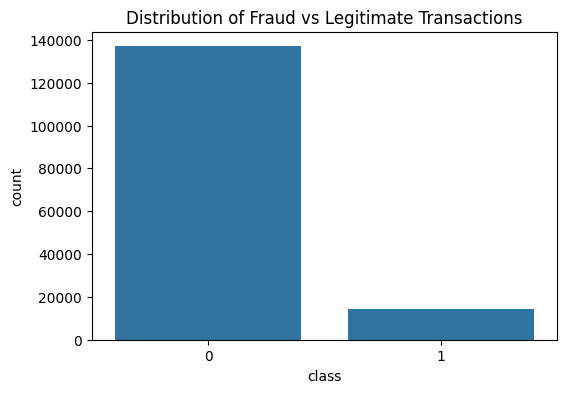

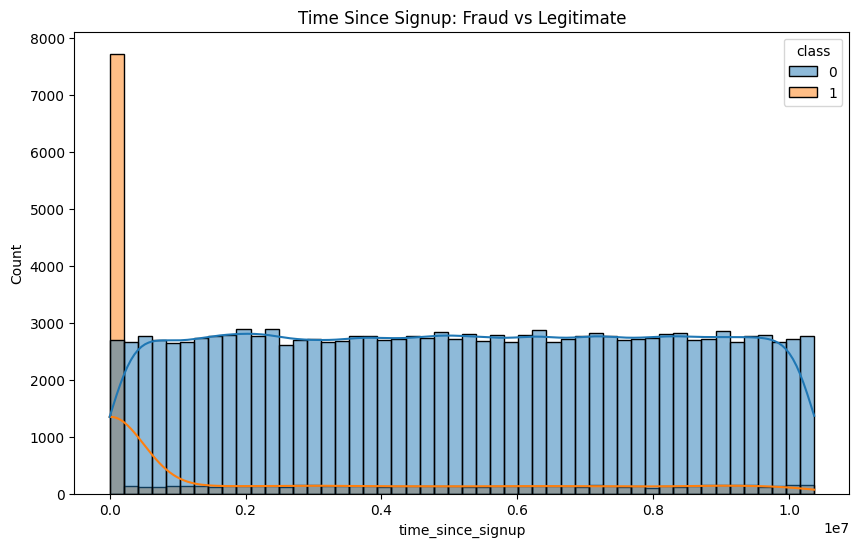

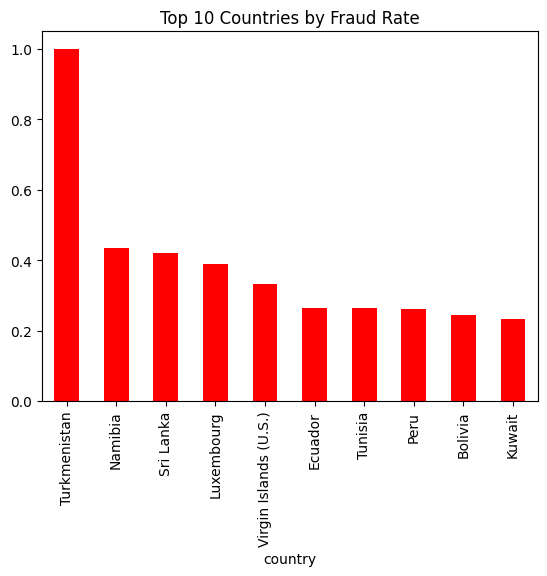

In [9]:
# A. Class Imbalance Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=merged_df)
plt.title('Distribution of Fraud vs Legitimate Transactions')

plt.show()

# B. Time Since Signup Visualization (The most important fraud signal)
plt.figure(figsize=(10,6))
sns.histplot(data=merged_df, x='time_since_signup', hue='class', bins=50, kde=True)
plt.title('Time Since Signup: Fraud vs Legitimate')

plt.show()

# C. Geolocation Fraud Pattern
country_fraud = merged_df.groupby('country')['class'].mean().sort_values(ascending=False).head(10)
country_fraud.plot(kind='bar', color='red')
plt.title('Top 10 Countries by Fraud Rate')

plt.show()

In [10]:
import joblib
import os

# Create the folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the preprocessor and the data splits
# The preprocessor is critical for transforming future 'unseen' data correctly
joblib.dump(preprocessor, '../data/processed/preprocessor.joblib')
joblib.dump((X_train_resampled, y_train_resampled), '../data/processed/train_data_resampled.joblib')
joblib.dump((X_test_transformed, y_test), '../data/processed/test_data_transformed.joblib')

print("All processed components saved successfully to ../data/processed/")

All processed components saved successfully to ../data/processed/
